# Data Preparation Day-1

Agenda Hari 1:
- Sesi 1: Why Data Preparation Matters
- Sesi 2: Acquiring Data
- Sesi 3: EDA — Kenali Datamu
- Sesi 4: Data Cleansing
- Sesi 5: Advanced Imputation
- Rekap Hari 1 + Q&A

## Why data preparation matters?


### CRISP DM Framework

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modelling
5. Evaluation
6. Deployment

## Acquiring Data

In [20]:
# Install required libraries
# !pip install -r requirements.txt

In [21]:
import pandas as pd

# CSV 
df = pd.read_csv('data/data.csv')

# # Dengan parameter penting:
# df = pd.read_csv('data/data.csv',
#     sep=',',
#     encoding='utf-8',        # ganti 'latin-1' jika error
#     na_values=[' ', 'N/A', '-'],
#     parse_dates=['tanggal'])

# print(str(df.dtypes))

# # Excel
# df = pd.read_excel('data/data.xlsx', sheet_name='Realisasi')

# # JSON
# df = pd.read_json('data/data.json')

# # Parquet (modern, 5-10x lebih cepat dari CSV)
# df = pd.read_parquet('data/data.parquet')

# Remote database
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# load_dotenv()

# conn_str = os.getenv('CONN_STR').strip()
# engine = create_engine(conn_str)
# df = pd.read_sql("SELECT * FROM public.data", engine)

# API -JSON
# import requests

# url = "https://training.ekos.my.id/data"
# response = requests.get(url)

# if response.status_code == 200:
#     data = response.json().get('data')
#     df = pd.DataFrame(data)

df

,id,name,age,email,tanggal,nilai
0,1,Alice,25.0,alice@example.com,2023-01-15,100.5
1,2,Bob,30.0,NaN,2023-02-20,NaN
2,3,Charlie,NaN,charlie@example.com,invalid-date,300.0
3,4,NaN,35.0,david@example.com,2023-04-10,400.0
4,5,David,40.0,eve@example.com,2023-05-25,500.0
5,6,Eve,45.0,NaN,2023-06-30,600.0
6,7,NaN,50.0,frank@example.com,NaN,700.0
7,8,Frank,NaN,grace@example.com,2023-08-05,800.0
8,9,Grace,55.0,NaN,2023-09-15,900.0
9,10,Hank,60.0,hank@example.com,2023-10-20,1000.0


In [22]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Load dataset kotor
telco_data = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_dirty = pd.read_csv(telco_data)
# df_dirty.info()

# # Model dengan data kotor — minimal preprocessing
df_dirty['TotalCharges'] = pd.to_numeric(df_dirty['TotalCharges'], errors='coerce')
df_dirty = df_dirty.fillna(0)
df_dirty['Churn'] = df_dirty['Churn'].map({'Stayed': 0, 'Churned': 1})

df_dirty = df_dirty.dropna(subset=['Churn'])
df_dirty['Churn'] = df_dirty['Churn'].astype(int)

# Ambil hanya kolom numerik dulu untuk demo cepat
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_dirty = df_dirty[num_cols]
y = df_dirty['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_dirty, y, test_size=0.2, random_state=42, stratify=y)

model_dirty = LogisticRegression(max_iter=1000)
model_dirty.fit(X_train, y_train)
# print('=== MODEL DATA KOTOR ===')
print(classification_report(y_test, model_dirty.predict(X_test)))

# # Kita akan revisit ini di akhir Hari 2 setelah data bersih
# # dan lihat perbedaan hasilnya!


              precision    recall  f1-score   support

           0       0.81      0.91      0.85      1035
           1       0.61      0.41      0.49       374

    accuracy                           0.77      1409
   macro avg       0.71      0.66      0.67      1409
weighted avg       0.76      0.77      0.76      1409



## EDA

In [23]:
telco_data = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_dirty = pd.read_csv(
    telco_data,
    # na_values=[' ', 'N/A', '-'],  # me-mapping nilai tertentu menjadi NA (pd.NA), misal " " -> na, N/A -> na
)

df_dirty.columns.__len__()

22

In [24]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null   str    
 4   Partner           7043 non-null   str    
 5   Dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   str    
 8   MultipleLines     7043 non-null   str    
 9   InternetService   7043 non-null   str    
 10  OnlineSecurity    7043 non-null   str    
 11  OnlineBackup      7043 non-null   str    
 12  DeviceProtection  7043 non-null   str    
 13  TechSupport       7043 non-null   str    
 14  StreamingTV       7043 non-null   str    
 15  StreamingMovies   7043 non-null   str    
 16  Contract          7043 non-null   str    
 17  Paperl

/Users/ekosupriyono/Presentations/data-preparation/.venv/lib/python3.14/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/ekosupriyono/Presentations/data-preparation/.venv/lib/python3.14/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: >

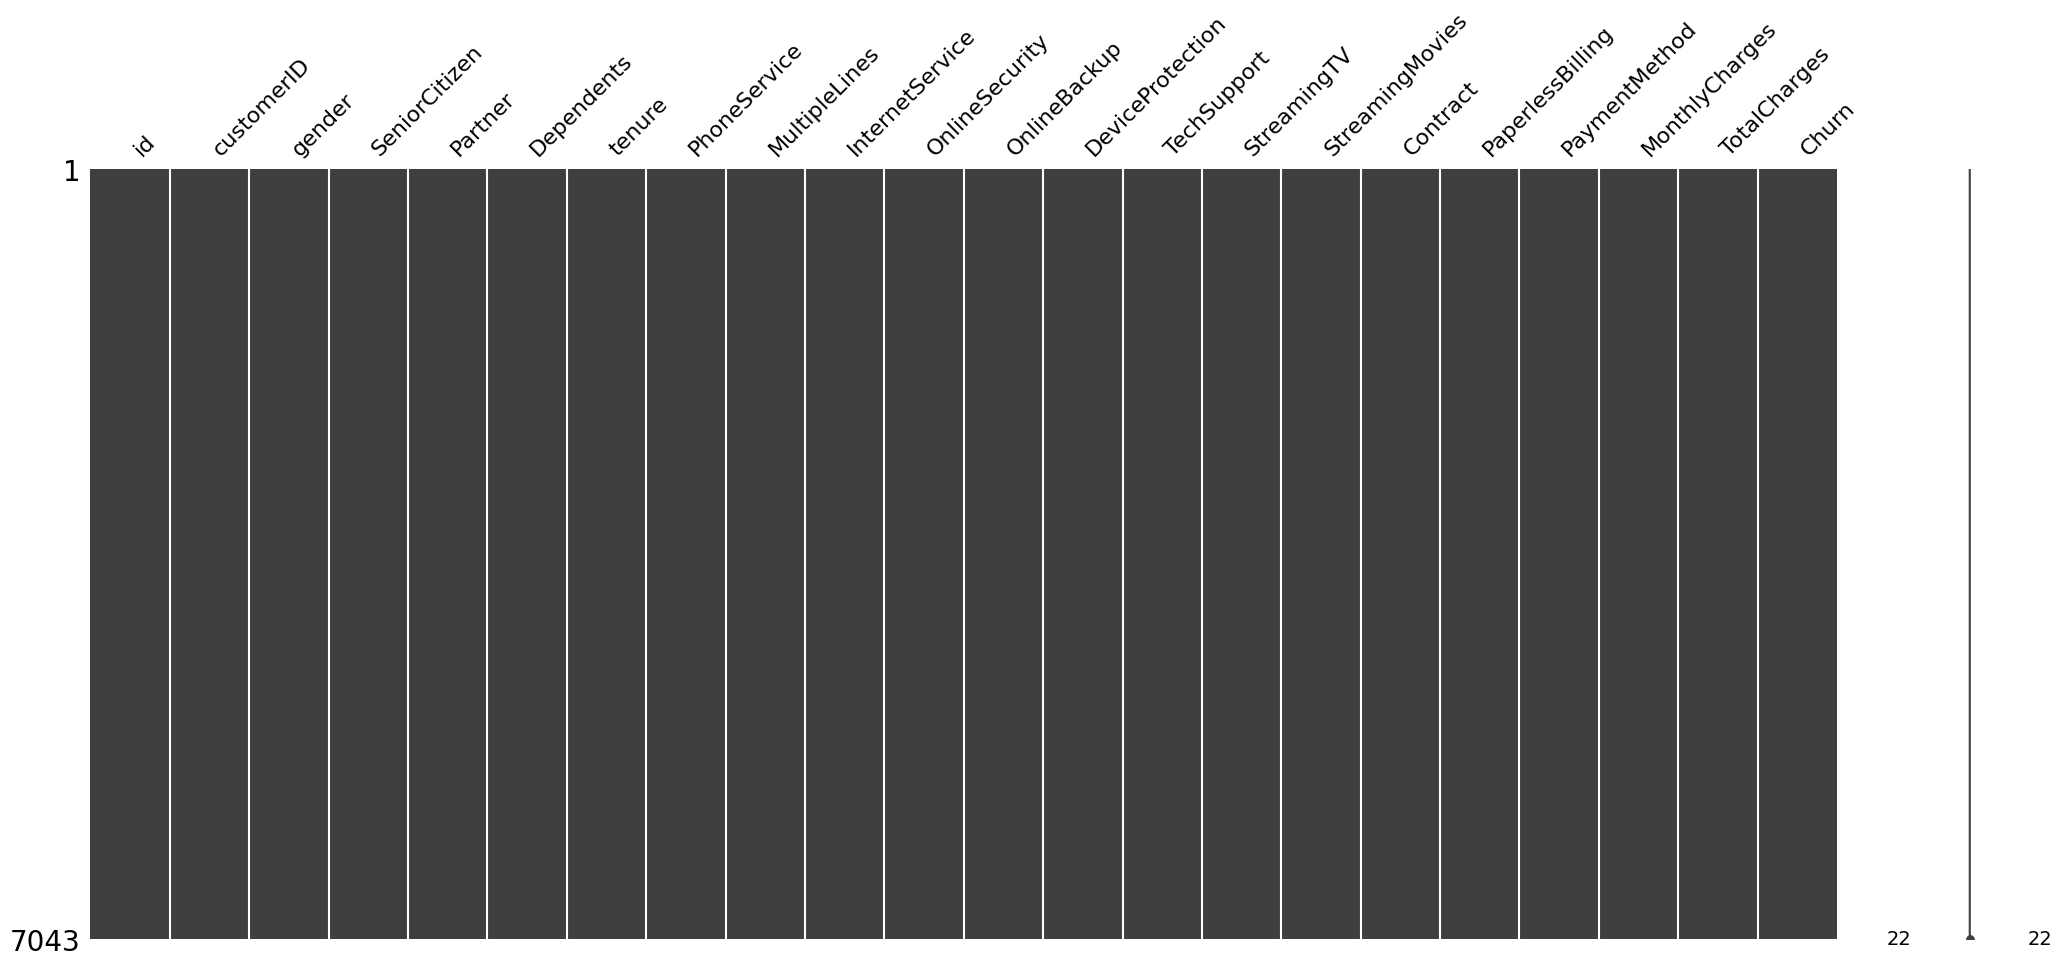

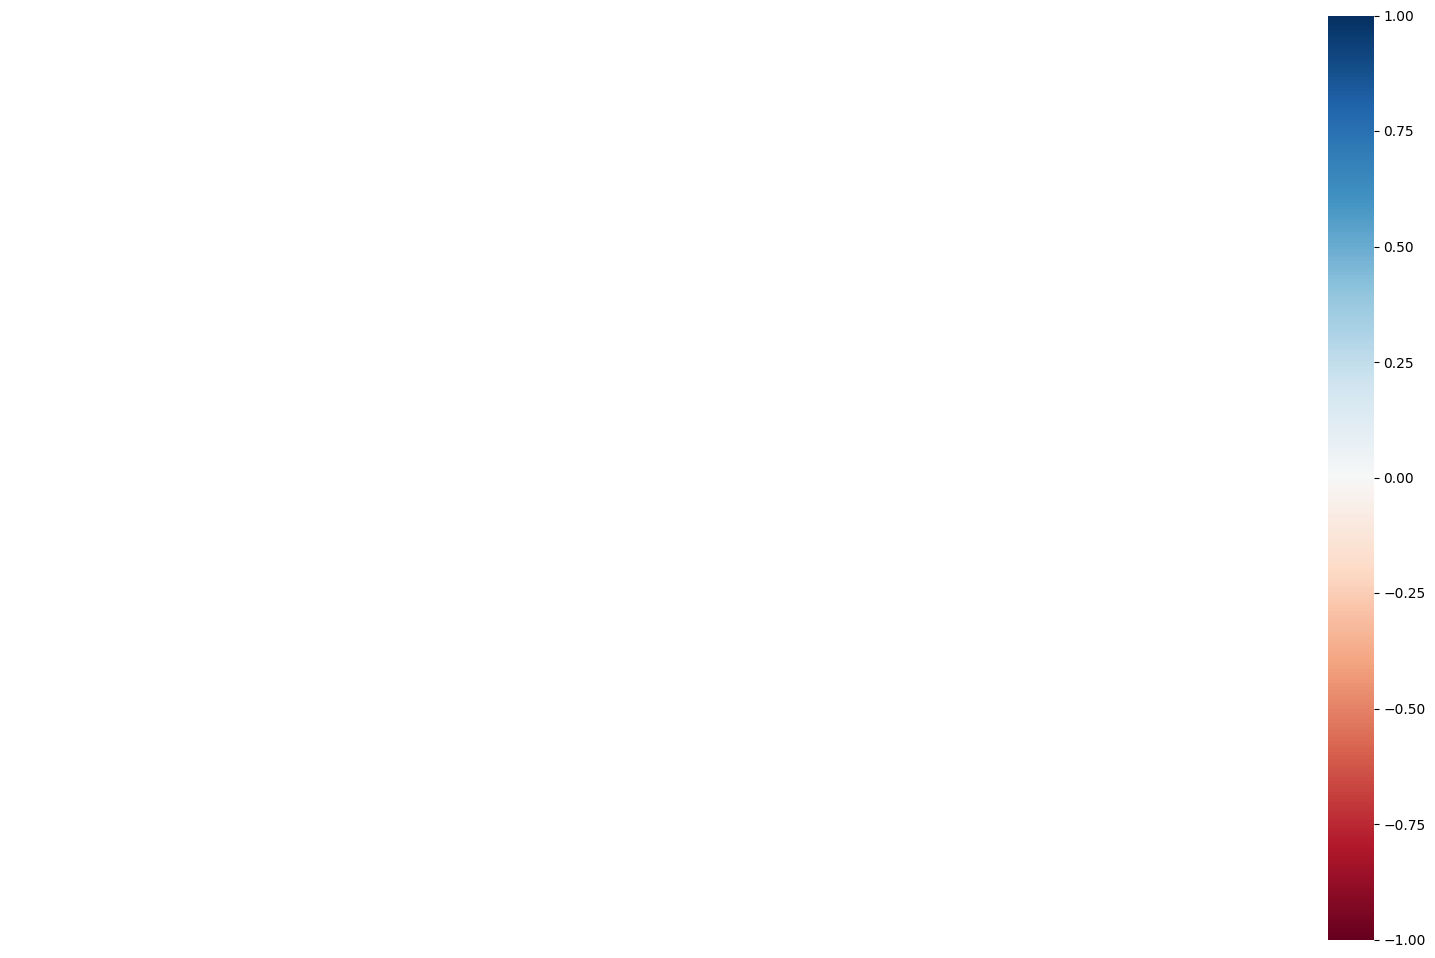

In [25]:
import seaborn as sns
import missingno as msno
%matplotlib inline

# Distribusi kolom numerik
# df_dirty.select_dtypes('number').hist(bins=30)

# Boxplot deteksi outlier
# sns.boxplot(y=df_dirty['MonthlyCharges'])

# Missing values map
msno.matrix(df_dirty)
msno.heatmap(df_dirty)  # korelasi missing


In [26]:
df_dirty[df_dirty['TotalCharges'].isna()]

# df_dirty.query("TotalCharges not ")

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [27]:
# tampilkan 11 data yang total charges nya NA, gunakan pandas
df_dirty[df_dirty['TotalCharges'].isnull()]

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [28]:
# Churn proportion (target variable)
df_dirty['Churn'].value_counts(normalize=True).round(3)
# Imbalanced!
# No: 0.735 Yes: 0.266

Churn
Stayed     0.735
Churned    0.265
Name: proportion, dtype: float64

In [29]:
df_dirty['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

## Data Cleansing

### [1] Memahami Tipe Data

Sebelum membersihkan data, kita perlu memahami tipe data setiap kolom.
Pandas menggunakan tipe berikut:

| Tipe Pandas | Keterangan | Contoh |
|-------------|------------|--------|
| `int64`     | Bilangan bulat | `tenure` |
| `float64`   | Bilangan desimal | `MonthlyCharges`, `TotalCharges` |
| `object`    | Teks / string (atau campuran) | `gender`, `Contract` |
| `bool`      | True / False | — |
| `datetime64`| Tanggal & waktu | — |
| `category`  | Kategori efisien (hemat memori) | — |

In [30]:
# Reload dataset mentah (sebelum ada perubahan apapun)
import pandas as pd

telco_data = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_dirty = pd.read_csv(telco_data)

# Ringkasan tipe data
print(df_dirty.dtypes)
print()
df_dirty.info()

id                    int64
customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null  

### [2] Memperbaiki Tipe Data

Kolom `TotalCharges` seharusnya numerik, tetapi terbaca sebagai `object` karena
ada nilai berupa spasi kosong `' '` di beberapa baris.
Kita harus mengkonversi secara eksplisit menggunakan `pd.to_numeric`.

In [31]:
my_text = "   hello world   "
my_text.strip()

'hello world'

In [32]:
telco_data = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_dirty = pd.read_csv(telco_data)

# Lihat masalahnya
print('Tipe sebelum:', df_dirty['TotalCharges'].dtype)
print('Contoh nilai bermasalah:')
print(df_dirty[df_dirty['TotalCharges'].str.strip() == ''][['customerID', 'TotalCharges']].head())

# Perbaiki: paksa ke numerik, nilai yang tidak bisa dikonversi jadi NaN
df_dirty['TotalCharges'] = pd.to_numeric(df_dirty['TotalCharges'], errors='coerce')
print('\nTipe sesudah:', df_dirty['TotalCharges'].dtype)
print('Missing values di TotalCharges:', df_dirty['TotalCharges'].isna().sum())

Tipe sebelum: str
Contoh nilai bermasalah:
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             

Tipe sesudah: float64
Missing values di TotalCharges: 11


### [3] Menghapus Data Duplikat

Data duplikat dapat muncul akibat proses ETL yang berulang atau join yang salah.
Gunakan `.duplicated()` untuk mendeteksi dan `.drop_duplicates()` untuk menghapus.

In [33]:
# Cek duplikat
print('Jumlah baris duplikat:', df_dirty.duplicated().sum())
print('Jumlah baris duplikat (berdasarkan customerID dan gender):', df_dirty.duplicated(subset=['customerID', 'gender']).sum())

# Hapus duplikat — keep='first' mempertahankan kemunculan pertama
df_dirty = df_dirty.drop_duplicates(subset='customerID', keep='first')
print('Jumlah baris setelah drop_duplicates:', len(df_dirty))

Jumlah baris duplikat: 0
Jumlah baris duplikat (berdasarkan customerID dan gender): 0
Jumlah baris setelah drop_duplicates: 7043


### [4] Menangani Missing Values

Ada dua strategi utama:

| Strategi | Kapan digunakan | Fungsi |
|----------|----------------|--------|
| **Drop** | Data hilang < 5%, kolom tidak penting | `.dropna()` |
| **Impute** | Data hilang > 5%, kolom penting | `.fillna()` / SimpleImputer |

In [34]:
# Ringkasan missing values
missing = df_dirty.isnull().sum()
missing_pct = (missing / len(df_dirty) * 100).round(2)
print(missing[missing > 0].to_frame('count').assign(pct=missing_pct))

# Strategi 1 — Drop baris yang TotalCharges-nya NaN (hanya ~11 baris, < 1%)
df_drop = df_dirty.dropna(subset=['TotalCharges'])
print('\nSetelah dropna:', len(df_drop), 'baris')

# Strategi 2 — Imputasi numerik dengan median
median_tc = df_dirty['TotalCharges'].median()
df_imputed = df_dirty.copy()
df_imputed['TotalCharges'] = df_imputed['TotalCharges'].fillna(median_tc)
print('Imputasi median TotalCharges:', median_tc)

              count   pct
TotalCharges     11  0.16

Setelah dropna: 7032 baris
Imputasi median TotalCharges: 1397.475


In [35]:
df_drop.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7032 non-null   int64  
 1   customerID        7032 non-null   str    
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   str    
 4   Partner           7032 non-null   str    
 5   Dependents        7032 non-null   str    
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   str    
 8   MultipleLines     7032 non-null   str    
 9   InternetService   7032 non-null   str    
 10  OnlineSecurity    7032 non-null   str    
 11  OnlineBackup      7032 non-null   str    
 12  DeviceProtection  7032 non-null   str    
 13  TechSupport       7032 non-null   str    
 14  StreamingTV       7032 non-null   str    
 15  StreamingMovies   7032 non-null   str    
 16  Contract          7032 non-null   str    
 17  PaperlessBi

### [5] Pipeline Lengkap — `clean_df`

Setelah memahami setiap langkah secara terpisah, kita gabungkan semuanya
ke dalam satu fungsi yang bisa digunakan ulang.

In [36]:
df_dirty['MultipleLines'].mode()[0]

'No'

In [37]:
import pandas as pd

def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Fix tipe data
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # 2. Drop NA hanya jika masih ada
    df = df.dropna(subset=['TotalCharges'])

    # 3. Impute numerik (median)
    if 'MonthlyCharges' in df.columns:
        # Dihitung dulu mediannya
        median_val = df['MonthlyCharges'].median()
        # Median digunakan untuk impute jika MonthlyCharges `na`
        df['MonthlyCharges'] = df['MonthlyCharges'].fillna(median_val)

    # 4. Impute kategorikal (modus)
    if 'MultipleLines' in df.columns:
        if not df['MultipleLines'].mode().empty:
            mode_val = df['MultipleLines'].mode()[0]
            df['MultipleLines'] = df['MultipleLines'].fillna(mode_val)

    # 5. Final check
    if df.isnull().sum().sum() != 0:
        raise ValueError("Masih ada missing values!")

    return df

In [38]:
df = clean_df(df_dirty)

df.head()

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


## Penanganan Outlier

**Outlier** adalah nilai yang jauh menyimpang dari distribusi normal data.
Keberadaannya bisa disebabkan oleh:
- Kesalahan input / pengukuran
- Kejadian ekstrem yang valid (misal pelanggan dengan tagihan sangat tinggi)

Sebelum menghapus atau mengubah outlier, selalu tanyakan: **apakah nilai ini masuk akal secara bisnis?**

### [1] Mendeteksi Outlier

Ada dua metode deteksi yang umum digunakan:

| Metode | Cara Kerja | Cocok untuk |
|--------|-----------|-------------|
| **IQR** (Interquartile Range) | Outlier = nilai di luar `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` | Distribusi skewed / tidak normal |
| **Z-Score** | Outlier = nilai dengan `\|z\| > 3` (> 3 stddev dari mean) | Distribusi mendekati normal |

Visualisasi paling cepat untuk melihat outlier adalah **boxplot**.

In [39]:
df.head()

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7032 non-null   int64  
 1   customerID        7032 non-null   str    
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   str    
 4   Partner           7032 non-null   str    
 5   Dependents        7032 non-null   str    
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   str    
 8   MultipleLines     7032 non-null   str    
 9   InternetService   7032 non-null   str    
 10  OnlineSecurity    7032 non-null   str    
 11  OnlineBackup      7032 non-null   str    
 12  DeviceProtection  7032 non-null   str    
 13  TechSupport       7032 non-null   str    
 14  StreamingTV       7032 non-null   str    
 15  StreamingMovies   7032 non-null   str    
 16  Contract          7032 non-null   str    
 17  PaperlessBi

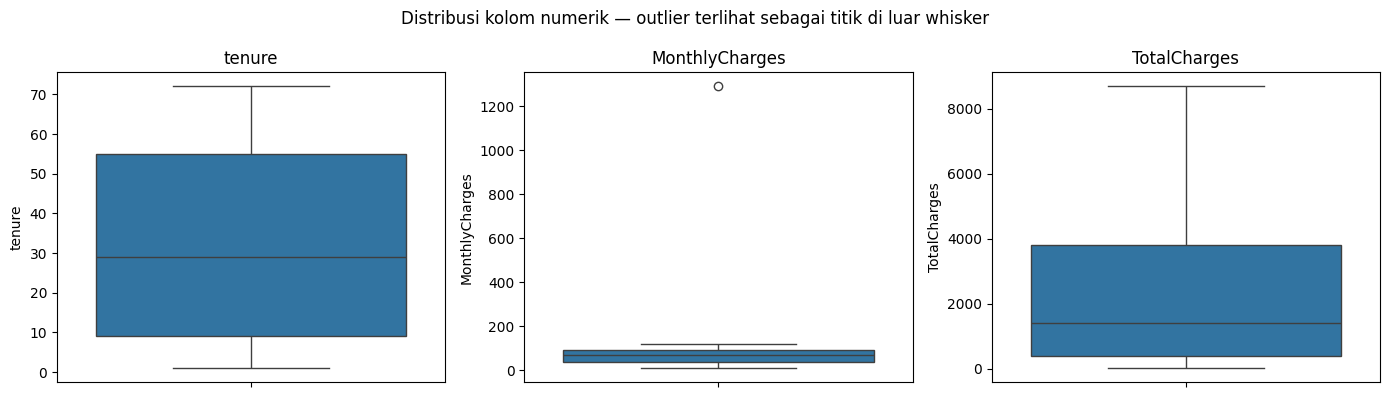

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle('Distribusi kolom numerik — outlier terlihat sebagai titik di luar whisker')
plt.tight_layout()
plt.show()

### [2] Menangani Outlier

Setelah terdeteksi, ada tiga pilihan penanganan:

| Strategi | Kapan digunakan | Cara |
|----------|----------------|------|
| **Drop** | Outlier akibat error data, jumlah sedikit | `df[mask]` — filter baris di luar batas |
| **Winsorizing / Capping** | Outlier valid tapi ekstrem, ingin mempertahankan baris | `.clip(lower, upper)` |
| **Transformasi** | Distribusi sangat skewed | `np.log1p()`, `np.sqrt()` |

In [42]:
# Metode 1: IQR
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Metode 2: Z-Score
from scipy import stats
z = abs(stats.zscore(df['tenure']))
outliers = df[z > 3]

# Winsorizing (capping) — ganti dengan batas IQR
df['charges_capped'] = df['MonthlyCharges'].clip(lower=lower, upper=upper)

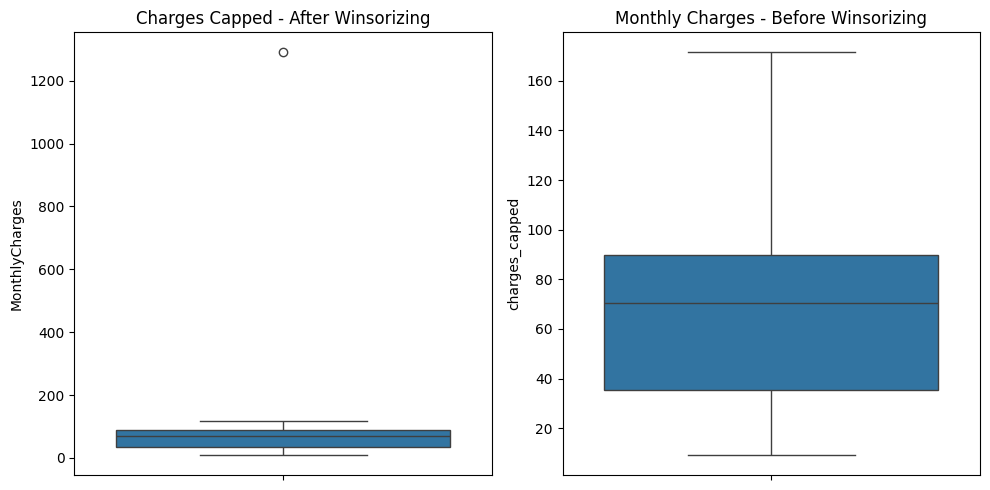

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot pertama
sns.boxplot(y=df['MonthlyCharges'], ax=axes[0])
axes[1].set_title('Monthly Charges - Before Winsorizing')

# Plot kedua
sns.boxplot(y=df['charges_capped'], ax=axes[1])
axes[0].set_title('Charges Capped - After Winsorizing')

plt.tight_layout()
plt.show()

---
## Real-Time Data Pipeline

Pada sesi ini kita akan mensimulasikan pipeline data **sensor IoT** yang masuk secara
real-time, mulai dari akuisisi hingga dashboard monitoring — mengikuti alur **CRISP-DM**.

```
API Endpoint  →  [1] Business Understanding
              →  [2] Data Understanding  (fetch & explore)
              →  [3] Data Preparation   (cleanse, fix, outlier)
              →  [4] Dashboard          (visualisasi hasil bersih)
```

> **Simulasi stream:** setiap kali kamu memanggil endpoint, kamu mendapat 10 baris baru.
> Jalankan cell akuisisi berulang kali untuk mensimulasikan data yang terus masuk.

### [1] Business Understanding

| | |
|---|---|
| **Konteks** | Jaringan sensor IoT dipasang di 5 kota besar Indonesia untuk memantau kondisi lingkungan secara real-time. |
| **Problem** | Data mentah dari sensor sering kotor: nilai null, tipe data salah, duplikat, dan pembacaan ekstrem (outlier). |
| **Tujuan** | Membangun pipeline otomatis yang membersihkan data begitu masuk, lalu menampilkan dashboard kondisi terkini. |
| **Kriteria sukses** | Dashboard terupdate setiap batch, tidak ada nilai null atau tipe data salah di output akhir. |

**Skema data sensor & imperfeksi yang diketahui:**

| Kolom | Tipe Harapan | Imperfeksi | Frekuensi |
|-------|-------------|------------|-----------|
| `sensor_id` | `str` | Format rusak, misal `SEN-3_ERROR` | ~12% |
| `location` | `str` | — | — |
| `temperature_c` | `float` | `null` + outlier fisik (80–150 °C) | ~15% null, ~10% outlier |
| `humidity_pct` | `float` | String `"N/A"` + `null` | ~10% dirty, ~5% null |
| `pressure_hpa` | `float` | `null` + outlier fisik (1100–1300 hPa) | ~10% null, ~8% outlier |
| `battery_pct` | `float` | `null` | ~5% |
| `signal_strength` | `str` | `"UNKNOWN"` atau `null`; nilai valid: `strong`, `medium`, `weak` | bervariasi |
| `reading_count` | `int` | String `"error"` (mixed type) | ~8% |

### [2] Data Understanding — Fetch & Eksplorasi

Langkah pertama: ambil data dari endpoint dan pahami kondisi aktualnya.

In [44]:
import requests
import pandas as pd

ENDPOINT = "https://training.ekos.my.id/api/realtime-data"

def fetch_batch() -> pd.DataFrame:
    """Ambil satu batch (10 baris) dari endpoint sensor."""
    resp = requests.get(ENDPOINT, timeout=10)
    resp.raise_for_status()
    payload = resp.json()
    return pd.DataFrame(payload['data'])

# Ambil satu batch untuk eksplorasi
df_raw = fetch_batch()
print(f"Jumlah baris: {len(df_raw)}")
df_raw

Jumlah baris: 10


,row_id,sensor_id,location,temperature_c,humidity_pct,pressure_hpa,battery_pct,signal_strength,reading_count
0,1,SEN-010,Makassar,32.79,52.3,1015.7,NaN,weak,236
1,2,SEN-1_ERROR,Surabaya,28.32,72.4,1021.4,80.4,weak,error
2,3,SEN-1_ERROR,Medan,32.46,87.3,NaN,NaN,medium,273
3,4,SEN-013,Surabaya,20.55,60.3,997.2,NaN,UNKNOWN,242
4,5,SEN-010,Medan,NaN,61.3,1014.2,6.5,UNKNOWN,205
5,6,SEN-4_ERROR,Jakarta,25.38,N/A,1013.5,79.8,medium,110
6,7,SEN-016,Medan,29.92,69.4,1013.6,NaN,UNKNOWN,90
7,8,SEN-017,Medan,28.49,88.2,999.0,79.4,weak,21
8,9,SEN-016,Makassar,23.75,65.9,1011.4,85.5,weak,183
9,10,SEN-015,Bandung,29.64,50.0,999.8,48.7,weak,439


In [45]:
# Tipe data awal — sebelum apapun
print("=== dtypes ===")
# print(df_raw.dtypes)
print()

# Missing values (termasuk string 'N/A', 'error', 'UNKNOWN')
print("=== Nilai null aktual ===")
# print(df_raw.isnull().sum())
print()

# Nilai unik per kolom kategorikal — tampak imperfeksinya
# print("=== signal_strength — nilai unik ===")
# print(df_raw['signal_strength'].unique())
# print()
# print("=== humidity_pct — nilai unik (sample) ===")
# print(df_raw['humidity_pct'].unique())
# print()
# print("=== reading_count — nilai unik ===")
# print(df_raw['reading_count'].unique())
# print()
# print("=== sensor_id — semua nilai ===")
# print(df_raw['sensor_id'].unique())
# print()

# Deteksi sensor_id dengan format rusak (valid: SEN-XXX)
# import re
# valid_id = df_raw['sensor_id'].str.match(r'^SEN-\d{3}$', na=False)
# invalid_id = ~df_raw['sensor_id'].str.match(r'^SEN-\d{3}$', na=False)
# print(f"sensor_id valid: {valid_id.sum()}")
# print(f"sensor_id invalid: {invalid_id.sum()}")
# print(df_raw[invalid_id][['sensor_id']])
# print()

# Deteksi outlier temperature_c (tidak mungkin 80-150°C di Indonesia)
df_raw_temp = pd.to_numeric(df_raw['temperature_c'], errors='coerce')
print(f"temperature_c outlier (>50C atau <=10C): {((df_raw_temp > 50) | (df_raw_temp <= 10)).sum()}")
df_raw_temp


# Deteksi outlier pressure_hpa
press_numeric = pd.to_numeric(df_raw['pressure_hpa'], errors='coerce')
print(f"pressure_hpa outlier (>1100 hPa atau <800 hPa): {(press_numeric > 1100).sum() + (press_numeric < 800).sum()}")

=== dtypes ===

=== Nilai null aktual ===

temperature_c outlier (>50C atau <=10C): 0
pressure_hpa outlier (>1100 hPa atau <800 hPa): 0


### [3] Data Preparation — Pipeline Pembersihan

Dari eksplorasi di atas kita menemukan **7 masalah** yang harus ditangani secara berurutan:

| # | Masalah | Kolom | Strategi |
|---|---------|-------|----------|
| 1 | `sensor_id` format rusak (`SEN-3_ERROR`) | `sensor_id` | Filter pakai regex, baris invalid → drop |
| 2 | String tidak valid (`"N/A"`, `"error"`) | `humidity_pct`, `reading_count` | Cast ke numerik → NaN |
| 3 | Standarisasi kategori (`"UNKNOWN"`, `null`) | `signal_strength` | Lowercase + peta ke nilai valid atau `"unknown"` |
| 4 | Outlier fisik `temperature_c` (80–150 °C tidak mungkin) | `temperature_c` | Nilai di luar range → NaN sebelum imputasi |
| 5 | Outlier fisik `pressure_hpa` (> 1100 hPa tidak realistis) | `pressure_hpa` | Winsorizing ke batas fisik valid |
| 6 | Missing values numerik (~5–15%) | semua kolom float | Imputasi median per lokasi, fallback global |
| 7 | Tipe data akhir tidak sesuai | `reading_count` | Cast ke `Int64` (nullable int) |

In [46]:
# lambda function 
a_list = [1, 2, 3, 4, 5]

a_list_squared = list(map(lambda x: x**2, a_list))
print(a_list_squared)

[1, 4, 9, 16, 25]


In [47]:
import numpy as np
from scipy import stats

NUMERIC_COLS = ['temperature_c', 'humidity_pct', 'pressure_hpa', 'battery_pct', 'reading_count']
PRESSURE_MAX = 1100.0   # hPa — batas fisik realistis di permukaan bumi
PRESSURE_MIN = 870.0
df_raw = fetch_batch()


def clean_sensor_batch(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Langkah 1: Cast ke numerik (string 'N/A', 'error' → NaN) ---
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- Langkah 2: Standarisasi signal_strength ---
    # strong, medium, weak, unknown
    df['signal_strength'] = (
        df['signal_strength'].str.lower().fillna('unknown')
    )

    # --- Langkah 3: Imputasi missing values dengan median per lokasi ---
    # jika data yang dikembalikan semua NA maka gunakan median global
    for col in ['temperature_c', 'humidity_pct', 'pressure_hpa', 'battery_pct']:
        df[col] = df.groupby('location')[col].transform(
            lambda x:  x.fillna(x.median())
        )
        df[col] = df[col].fillna(df[col].median())

    # reading_count: imputasi dengan median global
    df['reading_count'] = df['reading_count'].fillna(df['reading_count'].median())

    # --- Langkah 4: Outlier pressure_hpa — cap ke batas fisik realistis ---
    df['pressure_hpa'] = df['pressure_hpa'].clip(lower=PRESSURE_MIN, upper=PRESSURE_MAX)

    # --- Langkah 5: Hapus duplikat sensor_id — keep last (paling baru) ---
    df = df.drop_duplicates(subset='sensor_id', keep='last')

    # --- Langkah 6: Perbaiki tipe akhir ---
    df['reading_count'] = df['reading_count'].astype(int)

    # --- Validasi akhir ---
    remaining_null = df.isnull().sum().sum()
    if remaining_null != 0:
        print(f"Warning: Masih ada {remaining_null} missing values setelah pembersihan!")
        print(df.isnull().sum())

    return df


# Jalankan pipeline pada batch yang sudah kita fetch
df_clean = clean_sensor_batch(df_raw)

print(f"Raw: {len(df_raw)} baris → Clean: {len(df_clean)} baris")
print(f"Null tersisa: {df_clean.isnull().sum().sum()}")
df_clean

Raw: 10 baris → Clean: 10 baris
Null tersisa: 0


,row_id,sensor_id,location,temperature_c,humidity_pct,pressure_hpa,battery_pct,signal_strength,reading_count
0,1,SEN-2_ERROR,Medan,28.56,77.80,1100.0,80.1,weak,326
1,2,SEN-005,Surabaya,23.18,80.70,1017.7,54.1,medium,500
2,3,SEN-012,Medan,29.16,93.10,1100.0,16.4,strong,315
3,4,SEN-013,Makassar,23.77,88.50,1015.1,9.4,weak,278
4,5,SEN-018,Bandung,23.14,82.30,996.9,72.0,strong,281
5,6,SEN-002,Jakarta,29.34,44.40,1017.7,20.3,weak,267
6,7,SEN-011,Bandung,28.48,55.30,1005.2,97.0,medium,449
7,8,SEN-010,Medan,120.23,85.45,1100.0,61.2,unknown,142
8,9,SEN-3_ERROR,Surabaya,23.18,74.20,1024.8,74.8,unknown,281
9,10,SEN-1_ERROR,Makassar,25.44,47.30,1016.2,80.7,unknown,194


In [48]:
# Verifikasi tipe data akhir
print(df_clean.dtypes)
print()
df_clean.describe()

row_id               int64
sensor_id              str
location               str
temperature_c      float64
humidity_pct       float64
pressure_hpa       float64
battery_pct        float64
signal_strength        str
reading_count        int64
dtype: object



,row_id,temperature_c,humidity_pct,pressure_hpa,battery_pct,reading_count
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,35.448000,72.905000,1039.360000,56.600000,303.300000
std,3.02765,29.907008,17.515619,42.526624,30.772643,106.190657
min,1.00000,23.140000,44.400000,996.900000,9.400000,142.000000
25%,3.25000,23.327500,60.025000,1015.375000,28.750000,269.750000
50%,5.50000,26.960000,79.250000,1017.700000,66.600000,281.000000
75%,7.75000,29.010000,84.662500,1081.200000,78.775000,323.250000
max,10.00000,120.230000,93.100000,1100.000000,97.000000,500.000000


### [4] Dashboard — Monitoring Real-Time

Setelah data bersih, kita buat dashboard yang **polling otomatis setiap 5 detik**.
Tekan tombol **⏹ Stop** untuk menghentikan loop, atau interrupt kernel (`■`) kapan saja.

> **Cara kerja:** setiap siklus memanggil `fetch_batch()` → `clean_sensor_batch()` → render ulang dashboard.


In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

def run_dashboard(n_batches: int = 1):
    """
    Fetch n_batches, jalankan pipeline, tampilkan dashboard.
    Catatan: clear_output ditangani di luar fungsi agar widget tidak ikut terhapus.
    """
    frames = []
    for _ in range(n_batches):
        raw = fetch_batch()
        clean = clean_sensor_batch(raw)
        frames.append(clean)

    data = pd.concat(frames, ignore_index=True)

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Sensor Dashboard  |  {len(data)} sensor readings  |  {n_batches} batch(es)',
                 fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # --- Plot 1: Suhu rata-rata per kota ---
    ax1 = fig.add_subplot(gs[0, 0])
    temp_by_loc = data.groupby('location')['temperature_c'].mean().sort_values()
    temp_by_loc.plot(kind='barh', ax=ax1, color='tomato')
    ax1.set_title('Suhu Rata-rata per Kota')
    ax1.set_xlabel('Suhu (°C)')
    ax1.set_ylabel('Kota')

    # --- Plot 2: Kelembaban rata-rata per kota ---
    ax2 = fig.add_subplot(gs[0, 1])
    hum_by_loc = data.groupby('location')['humidity_pct'].mean().sort_values()
    hum_by_loc.plot(kind='barh', ax=ax2, color='skyblue')
    ax2.set_title('Kelembaban Rata-rata per Kota')
    ax2.set_xlabel('Kelembaban (%)')
    ax2.set_ylabel('Kota')

    # --- Plot 3: Distribusi signal strength ---
    ax3 = fig.add_subplot(gs[0, 2])
    data['signal_strength'].value_counts().plot(
        kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'gold', 'lightcoral', 'lightgray']
    )
    ax3.set_title('Distribusi Signal Strength')
    ax3.set_ylabel('')

    # --- Plot 4: Battery level per sensor ---
    ax4 = fig.add_subplot(gs[1, 0])
    colors = data['battery_pct'].apply(
        lambda x: 'red' if x < 20 else ('orange' if x < 50 else 'green')
    )
    ax4.bar(data['sensor_id'], data['battery_pct'], color=colors)
    ax4.axhline(20, color='red', linestyle='--', linewidth=0.8, label='Kritis (<20%)')
    ax4.axhline(50, color='orange', linestyle='--', linewidth=0.8, label='Rendah (<50%)')
    ax4.set_title('Battery Level per Sensor')
    ax4.set_ylabel('%')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend(fontsize=7)

    # --- Plot 5: Pressure distribution (boxplot per kota) ---
    ax5 = fig.add_subplot(gs[1, 1])
    data.boxplot(column='pressure_hpa', by='location', ax=ax5)
    plt.sca(ax5); plt.title('Pressure (hPa) per Kota')
    ax5.set_xlabel('')

    # --- Plot 6: Tabel ringkasan KPI ---
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    kpi_rows = [
        ['Sensors',      str(data['sensor_id'].nunique())],
        ['Cities',       str(data['location'].nunique())],
        ['Avg Temp',     f"{data['temperature_c'].mean():.1f} °C"],
        ['Avg Humidity', f"{data['humidity_pct'].mean():.1f} %"],
        ['Low Battery',  f"{(data['battery_pct'] < 20).sum()} sensor"],
        ['Avg Readings', f"{data['reading_count'].mean():.0f}"],
    ]
    table = ax6.table(cellText=kpi_rows, colLabels=['KPI', 'Value'],
                      cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    ax6.set_title('KPI Summary', pad=20)

    plt.show()
    plt.close(fig)  # bebaskan memori


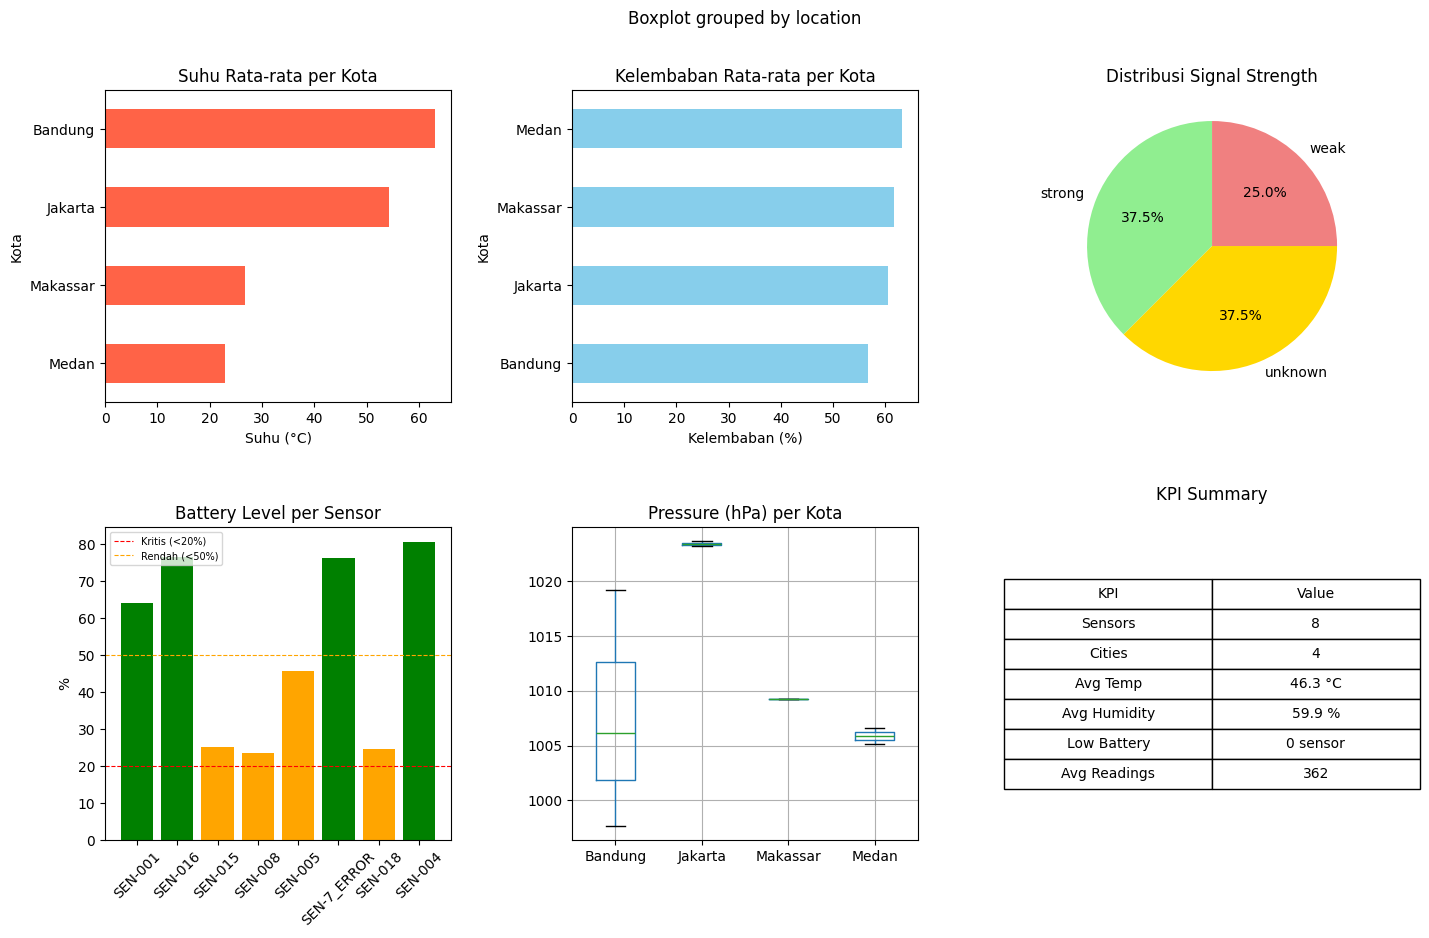

In [50]:
run_dashboard(n_batches=1)

In [ ]:
# ── Real-time polling: update dashboard setiap 5 detik ─────────────────────
# Tombol Stop bekerja karena dashboard berjalan di background thread,
# bukan di main kernel thread — sehingga widget event tetap diproses.
import time, threading
import ipywidgets as widgets  # https://pypi.org/project/ipywidgets/
from IPython.display import display

dash_out = widgets.Output()
stop_event = threading.Event()

stop_button = widgets.Button(description="Stop Dashboard", button_style='danger')
status_label = widgets.Label(value="Polling data every 5 seconds...")

def on_stop(b):
    stop_event.set()
    stop_button.disabled = True
    status_label.value = "Dashboard stopped..."

def poll_loop():
    while not stop_event.is_set():
        with dash_out:
            dash_out.clear_output(wait=True)
            run_dashboard(n_batches=1)
        time.sleep(5)

stop_button.on_click(on_stop)
display(widgets.HBox([stop_button, status_label]), dash_out)

t = threading.Thread(target=poll_loop, daemon=True)
t.start()

Output()